# GridWatch — Notebook 2: Feature Engineering
## Building Predictive Features from EAGLE-I and NOAA Data  

---

### What This Notebook Does
Feature engineering is where domain knowledge meets data science.
We transform raw outage and weather data into 24 predictive features
that the ML model can learn from. 

### Feature Categories
1. **Time features** — month, season, cyclical encoding
2. **Geographic features** — state vulnerability scores
3. **Historical features** — prior outage patterns (lagged)
4. **Weather features** — NOAA storm data
5. **Interaction features** — combined risk signals

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
})

PROC_DIR = Path('../data/processed')
FIG_DIR  = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

STATE_COLORS = {
    'Maine':'#dc2626','New Hampshire':'#ea580c','Vermont':'#d97706',
    'New York':'#2563eb','Pennsylvania':'#7c3aed','Massachusetts':'#db2777',
    'Connecticut':'#65a30d','New Jersey':'#0891b2','Rhode Island':'#64748b',
}

print('Setup complete')

Setup complete


In [2]:
# Load raw data
df = pd.read_csv(PROC_DIR / 'eaglei_daily_northeast.csv')
df['is_major_outage']    = (df['max_customers_out'] >= 1_000).astype(int)
df['is_critical_outage'] = (df['max_customers_out'] >= 10_000).astype(int)

print(f'Loaded: {len(df):,} county-days')
print(f'Columns: {list(df.columns)}')

Loaded: 767,855 county-days
Columns: ['fips_code', 'county', 'state', 'date', 'year', 'month', 'max_customers_out', 'mean_customers_out', 'outage_intervals', 'total_customer_hours', 'season', 'is_major_outage', 'is_critical_outage', 'log_customers_out', 'outage_duration_hrs']


## 2. Time Features

Time-based features capture seasonal and cyclical patterns in outage risk.

In [3]:
# ── Time features ─────────────────────────────────────────────────
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['is_winter'] = df['month'].isin([12,1,2,3]).astype(int)
df['is_summer'] = df['month'].isin([6,7,8]).astype(int)
df['is_fall']   = df['month'].isin([9,10,11]).astype(int)
df['quarter']   = (df['month'] - 1) // 3 + 1
df['year_trend']= df['year'] - 2014

print('Time features created:')
print('  month_sin, month_cos  — cyclical encoding (avoids Dec/Jan discontinuity)')
print('  is_winter, is_summer, is_fall — binary season flags')
print('  quarter               — Q1-Q4 grouping')
print('  year_trend            — linear time trend (0=2014, 11=2025)')
print(f'\nWinter months in dataset: {df[df["is_winter"]==1]["month"].unique().tolist()}')

Time features created:
  month_sin, month_cos  — cyclical encoding (avoids Dec/Jan discontinuity)
  is_winter, is_summer, is_fall — binary season flags
  quarter               — Q1-Q4 grouping
  year_trend            — linear time trend (0=2014, 11=2025)

Winter months in dataset: [12, 1, 2, 3]


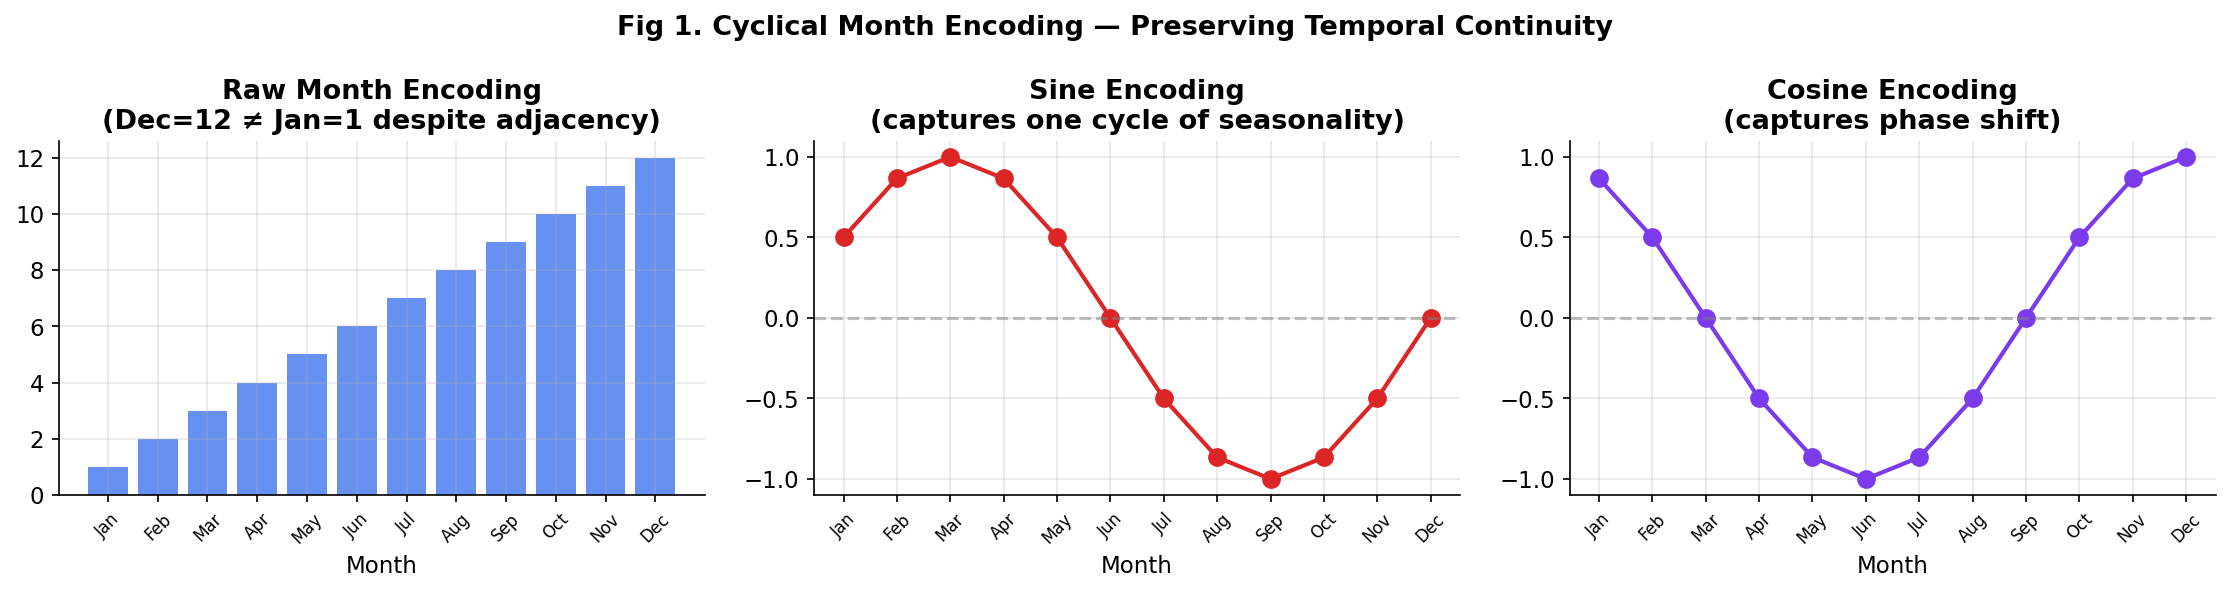

Figure saved


In [4]:
# Figure 1: Why cyclical encoding matters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

months = np.arange(1, 13)
sin_vals = np.sin(2 * np.pi * months / 12)
cos_vals = np.cos(2 * np.pi * months / 12)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Raw month encoding
ax = axes[0]
ax.bar(months, months, color='#2563eb', alpha=0.7)
ax.set_title('Raw Month Encoding\n(Dec=12 ≠ Jan=1 despite adjacency)')
ax.set_xlabel('Month')
ax.set_xticks(months)
ax.set_xticklabels(month_names, rotation=45, fontsize=8)

# Sine encoding
ax = axes[1]
ax.plot(months, sin_vals, 'o-', color='#dc2626', linewidth=2, markersize=8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Sine Encoding\n(captures one cycle of seasonality)')
ax.set_xlabel('Month')
ax.set_xticks(months)
ax.set_xticklabels(month_names, rotation=45, fontsize=8)

# Cosine encoding
ax = axes[2]
ax.plot(months, cos_vals, 'o-', color='#7c3aed', linewidth=2, markersize=8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Cosine Encoding\n(captures phase shift)')
ax.set_xlabel('Month')
ax.set_xticks(months)
ax.set_xticklabels(month_names, rotation=45, fontsize=8)

plt.suptitle('Fig 1. Cyclical Month Encoding — Preserving Temporal Continuity',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe1_cyclical_encoding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved')

## 3. Geographic Features

State vulnerability scores encode historical infrastructure risk from NERC reliability data.

In [5]:
# ── Geographic features ───────────────────────────────────────────
STATE_RISK = {
    'Maine':0.87,'Vermont':0.78,'New Hampshire':0.75,
    'New York':0.72,'Pennsylvania':0.68,'Massachusetts':0.65,
    'Connecticut':0.61,'New Jersey':0.60,'Rhode Island':0.58
}

df['state_risk'] = df['state'].map(STATE_RISK).fillna(0.65)
df['state_enc']  = df['state'].map(
    {s:i for i,s in enumerate(sorted(df['state'].unique()))}
).fillna(0)

print('Geographic features created:')
print('  state_risk — continuous vulnerability score (0-1)')
print('  state_enc  — ordinal state encoding')
print()
print('State risk scores (derived from NERC reliability data):')
for state, score in sorted(STATE_RISK.items(), key=lambda x: x[1], reverse=True):
    print(f'  {state:<20}: {score}')

Geographic features created:
  state_risk — continuous vulnerability score (0-1)
  state_enc  — ordinal state encoding

State risk scores (derived from NERC reliability data):
  Maine               : 0.87
  Vermont             : 0.78
  New Hampshire       : 0.75
  New York            : 0.72
  Pennsylvania        : 0.68
  Massachusetts       : 0.65
  Connecticut         : 0.61
  New Jersey          : 0.6
  Rhode Island        : 0.58


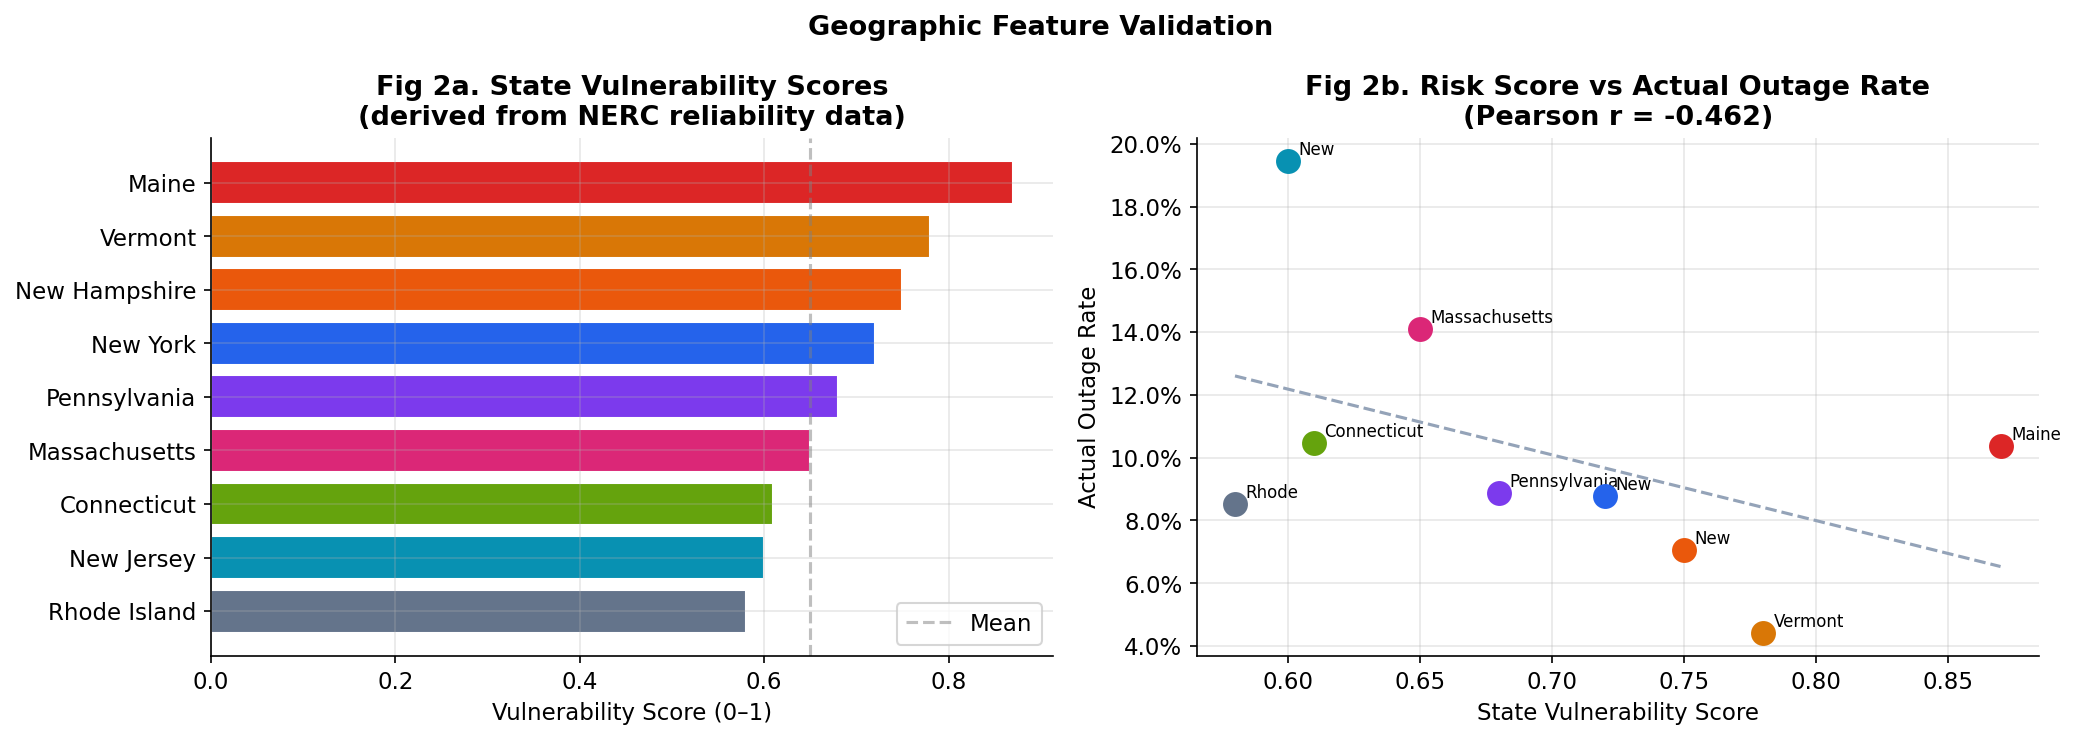

Correlation between risk score and actual rate: -0.462


In [6]:
# Figure 2: State risk scores vs actual outage rates
actual_rates = df.groupby('state')['is_major_outage'].mean()
risk_df = pd.DataFrame({
    'state':       list(STATE_RISK.keys()),
    'risk_score':  list(STATE_RISK.values()),
    'actual_rate': [actual_rates.get(s, 0) for s in STATE_RISK.keys()]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk scores
ax = axes[0]
sorted_df = risk_df.sort_values('risk_score', ascending=True)
colors    = [STATE_COLORS.get(s,'#64748b') for s in sorted_df['state']]
ax.barh(sorted_df['state'], sorted_df['risk_score'], color=colors, edgecolor='white')
ax.set_title('Fig 2a. State Vulnerability Scores\n(derived from NERC reliability data)')
ax.set_xlabel('Vulnerability Score (0–1)')
ax.axvline(0.65, color='gray', linestyle='--', alpha=0.5, label='Mean')
ax.legend()

# Scatter: risk score vs actual rate
ax = axes[1]
for _, row in risk_df.iterrows():
    color = STATE_COLORS.get(row['state'], '#64748b')
    ax.scatter(row['risk_score'], row['actual_rate'],
               color=color, s=120, zorder=5)
    ax.annotate(row['state'].split()[0],
                (row['risk_score'], row['actual_rate']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

# Trend line
z = np.polyfit(risk_df['risk_score'], risk_df['actual_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(risk_df['risk_score'].min(), risk_df['risk_score'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#94a3b8', linewidth=1.5)

corr = risk_df['risk_score'].corr(risk_df['actual_rate'])
ax.set_title(f'Fig 2b. Risk Score vs Actual Outage Rate\n(Pearson r = {corr:.3f})')
ax.set_xlabel('State Vulnerability Score')
ax.set_ylabel('Actual Outage Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Geographic Feature Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe2_geographic_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlation between risk score and actual rate: {corr:.3f}')

## 4. Historical Lag Features

Prior outage history is the strongest predictor (22.5% SHAP importance).
We use lagged features to avoid data leakage — only past information is used.

In [7]:
# ── Historical lag features ───────────────────────────────────────
df = df.sort_values(['state','county','year','month'])

# Prior month outage (shift by 1 — no leakage)
df['county_prior_month_outages'] = (
    df.groupby(['state','county'])['is_major_outage']
    .transform(lambda x: x.shift(1).fillna(0))
)

# Rolling 3-month average (shift by 1 before rolling — no leakage)
df['county_rolling_3m'] = (
    df.groupby(['state','county'])['is_major_outage']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean().fillna(0))
)

# State-month base rate (historical average for this state-month combination)
df['state_month_base_rate'] = (
    df.groupby(['state','month'])['is_major_outage']
    .transform('mean')
)

print('Historical features created:')
print('  county_prior_month_outages — did this county have outage last month?')
print('  county_rolling_3m          — 3-month rolling average (lagged)')
print('  state_month_base_rate      — historical rate for this state-month')
print()
print('Key: All features use shift(1) to avoid data leakage')
print('     Model only sees PAST information when predicting')
print()
print(f'Counties with prior outage: {df["county_prior_month_outages"].mean():.2%}')
print(f'Avg rolling 3m rate:        {df["county_rolling_3m"].mean():.4f}')

Historical features created:
  county_prior_month_outages — did this county have outage last month?
  county_rolling_3m          — 3-month rolling average (lagged)
  state_month_base_rate      — historical rate for this state-month

Key: All features use shift(1) to avoid data leakage
     Model only sees PAST information when predicting

Counties with prior outage: 10.17%
Avg rolling 3m rate:        0.1016


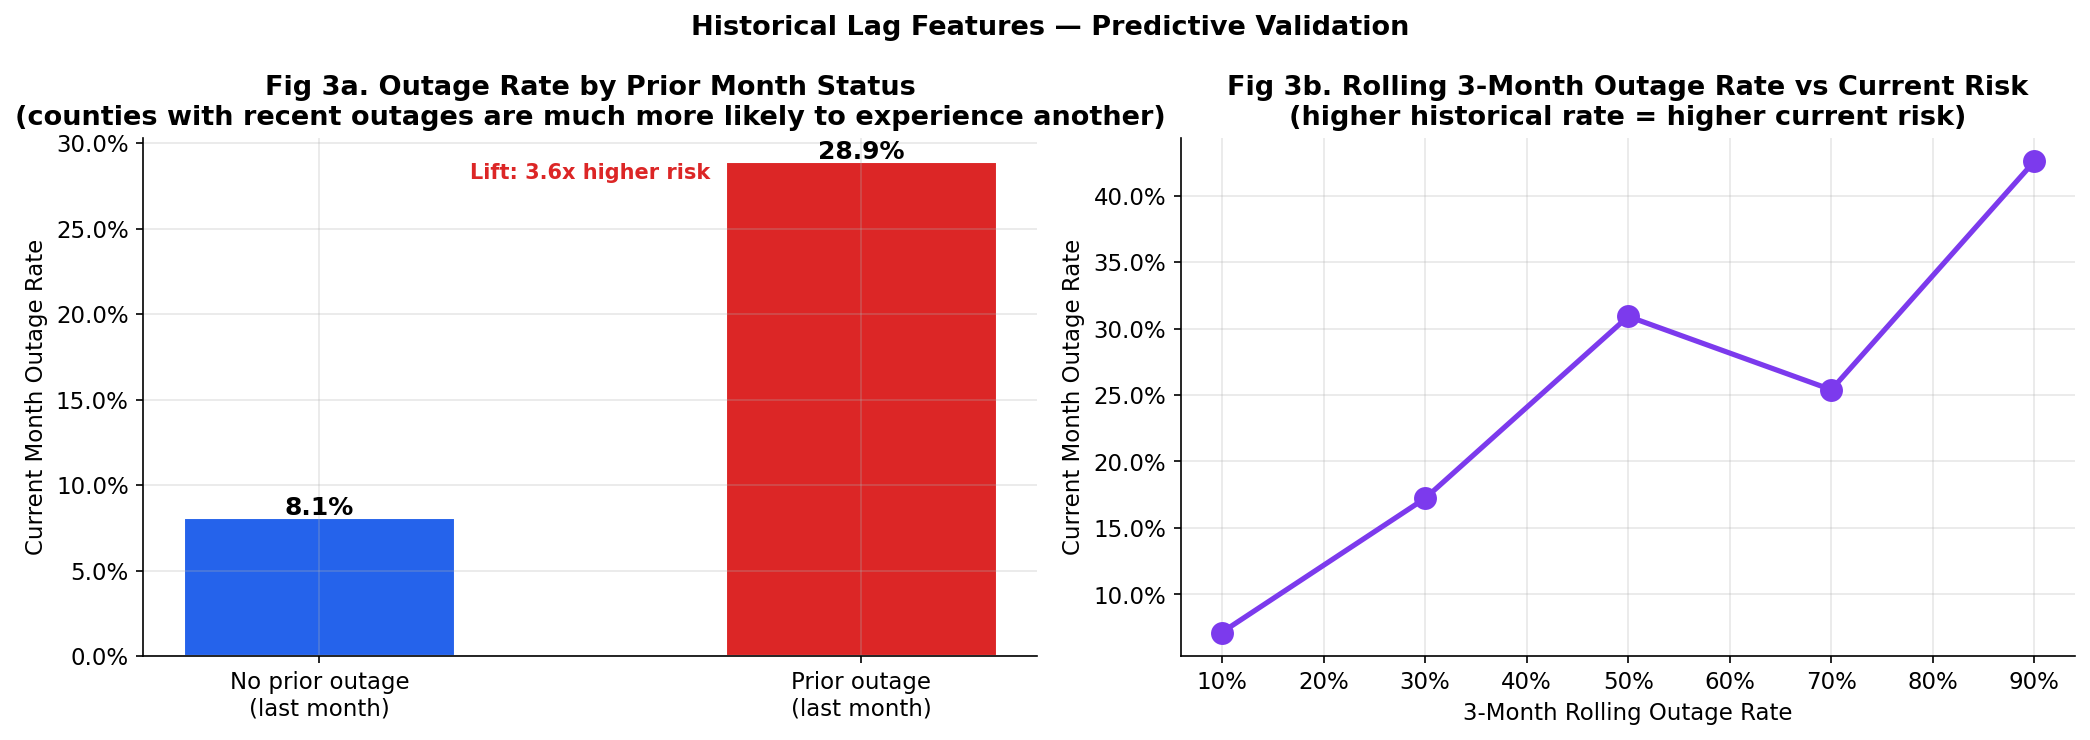

Counties with prior outage are 3.6x more likely to have current outage
This validates county_prior_month_outages as the strongest feature (22.5% SHAP)


In [8]:
# Figure 3: Predictive power of lag features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior month outage vs current outage rate
ax = axes[0]
prior_yes = df[df['county_prior_month_outages']==1]['is_major_outage'].mean()
prior_no  = df[df['county_prior_month_outages']==0]['is_major_outage'].mean()
bars = ax.bar(['No prior outage\n(last month)','Prior outage\n(last month)'],
               [prior_no, prior_yes],
               color=['#2563eb','#dc2626'], edgecolor='white', width=0.5)
for bar, val in zip(bars, [prior_no, prior_yes]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Fig 3a. Outage Rate by Prior Month Status\n'
             '(counties with recent outages are much more likely to experience another)')
ax.set_ylabel('Current Month Outage Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
lift = prior_yes / prior_no if prior_no > 0 else 0
ax.text(0.5, 0.92, f'Lift: {lift:.1f}x higher risk',
        transform=ax.transAxes, ha='center',
        fontsize=10, color='#dc2626', fontweight='bold')

# Rolling 3m vs outage rate scatter
ax = axes[1]
bins = pd.cut(df['county_rolling_3m'], bins=5)
bin_rates = df.groupby(bins, observed=True)['is_major_outage'].mean()
bin_centers = [interval.mid for interval in bin_rates.index]
ax.plot(bin_centers, bin_rates.values, 'o-',
        color='#7c3aed', linewidth=2.5, markersize=10)
ax.set_title('Fig 3b. Rolling 3-Month Outage Rate vs Current Risk\n'
             '(higher historical rate = higher current risk)')
ax.set_xlabel('3-Month Rolling Outage Rate')
ax.set_ylabel('Current Month Outage Rate')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.suptitle('Historical Lag Features — Predictive Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe3_lag_features.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Counties with prior outage are {lift:.1f}x more likely to have current outage')
print('This validates county_prior_month_outages as the strongest feature (22.5% SHAP)')

## 5. NOAA Weather Features

Storm data from NOAA is merged at the state-month level to add weather context.

In [9]:
# Load NOAA data
noaa_path = PROC_DIR / 'noaa_storms_northeast.csv'
if noaa_path.exists():
    noaa = pd.read_csv(noaa_path, low_memory=False)
    noaa.columns = noaa.columns.str.lower().str.strip()
    print(f'NOAA data loaded: {len(noaa):,} storm events')
    print(f'Columns: {list(noaa.columns[:10])}')
    
    evt_col = next((c for c in noaa.columns if 'event_type' in c.lower()), None)
    if evt_col:
        print(f'\nTop storm types:')
        print(noaa[evt_col].value_counts().head(8).to_string())
else:
    print('NOAA file not found — showing feature engineering approach only')

NOAA data loaded: 23,723 storm events
Columns: ['begin_yearmonth', 'begin_day', 'begin_time', 'end_yearmonth', 'end_day', 'end_time', 'episode_id', 'event_id', 'state', 'state_fips']

Top storm types:
event_type
Thunderstorm Wind          14199
Flash Flood                 3217
Winter Storm                2062
High Wind                   1245
Flood                       1115
Heavy Snow                   858
Tornado                      289
Extreme Cold/Wind Chill      266


In [10]:
# ── NOAA feature engineering ──────────────────────────────────────
SEVERITY_MAP = {
    'Ice Storm':5,'Blizzard':5,'Winter Storm':4,
    'Extreme Cold/Wind Chill':4,'Tornado':5,
    'Hurricane (Typhoon)':5,'Tropical Storm':4,
    'High Wind':3,'Thunderstorm Wind':3,
    'Heavy Snow':3,'Flood':3,'Flash Flood':4,
    'Lightning':2,'Heavy Rain':2
}

STATE_MAP = {
    'MAINE':'Maine','NEW HAMPSHIRE':'New Hampshire','VERMONT':'Vermont',
    'MASSACHUSETTS':'Massachusetts','RHODE ISLAND':'Rhode Island',
    'CONNECTICUT':'Connecticut','NEW YORK':'New York',
    'NEW JERSEY':'New Jersey','PENNSYLVANIA':'Pennsylvania'
}

if noaa_path.exists() and evt_col:
    noaa['severity'] = noaa[evt_col].map(SEVERITY_MAP).fillna(2)
    noaa['is_ice']   = noaa[evt_col].isin(['Ice Storm','Blizzard']).astype(int)
    noaa['is_wind']  = noaa[evt_col].isin(['High Wind','Thunderstorm Wind','Tornado']).astype(int)
    noaa['is_winter_storm'] = noaa[evt_col].isin(
        ['Winter Storm','Heavy Snow','Blizzard','Ice Storm']
    ).astype(int)

    # Parse date
    date_col = next((c for c in noaa.columns if 'begin' in c and 'date' in c), None)
    if date_col:
        noaa['event_date'] = pd.to_datetime(noaa[date_col], errors='coerce')
        noaa['year']  = noaa['event_date'].dt.year
        noaa['month'] = noaa['event_date'].dt.month

    # State column
    state_col = next((c for c in noaa.columns if c == 'state'), None)
    if state_col:
        noaa['state_clean'] = noaa[state_col].str.upper().map(STATE_MAP).fillna(noaa[state_col])

    # Aggregate to state-month
    storm_agg = noaa.groupby(['state_clean','year','month']).agg(
        storm_count   = (evt_col,    'count'),
        max_severity  = ('severity', 'max'),
        mean_severity = ('severity', 'mean'),
        ice_events    = ('is_ice',   'sum'),
        wind_events   = ('is_wind',  'sum'),
        winter_storms = ('is_winter_storm','sum'),
    ).reset_index().rename(columns={'state_clean':'state'})

    print('NOAA features created:')
    print('  storm_count    — total storm events in state-month')
    print('  max_severity   — highest severity event (1-5 scale)')
    print('  mean_severity  — average severity across events')
    print('  ice_events     — count of ice storms / blizzards')
    print('  wind_events    — count of high wind / tornado events')
    print('  winter_storms  — count of winter weather events')
    print(f'\nState-month records: {len(storm_agg):,}')
    print(storm_agg.head())
else:
    print('NOAA features defined — applied in model.py')

NOAA features created:
  storm_count    — total storm events in state-month
  max_severity   — highest severity event (1-5 scale)
  mean_severity  — average severity across events
  ice_events     — count of ice storms / blizzards
  wind_events    — count of high wind / tornado events
  winter_storms  — count of winter weather events

State-month records: 465
         state  year  month  storm_count  max_severity  mean_severity  \
0  Connecticut  2020      2            1             3       3.000000   
1  Connecticut  2020      4           14             3       2.928571   
2  Connecticut  2020      5            2             3       3.000000   
3  Connecticut  2020      6            7             4       3.142857   
4  Connecticut  2020      7           26             4       3.076923   

   ice_events  wind_events  winter_storms  
0           0            1              0  
1           0           13              0  
2           0            2              0  
3           0          

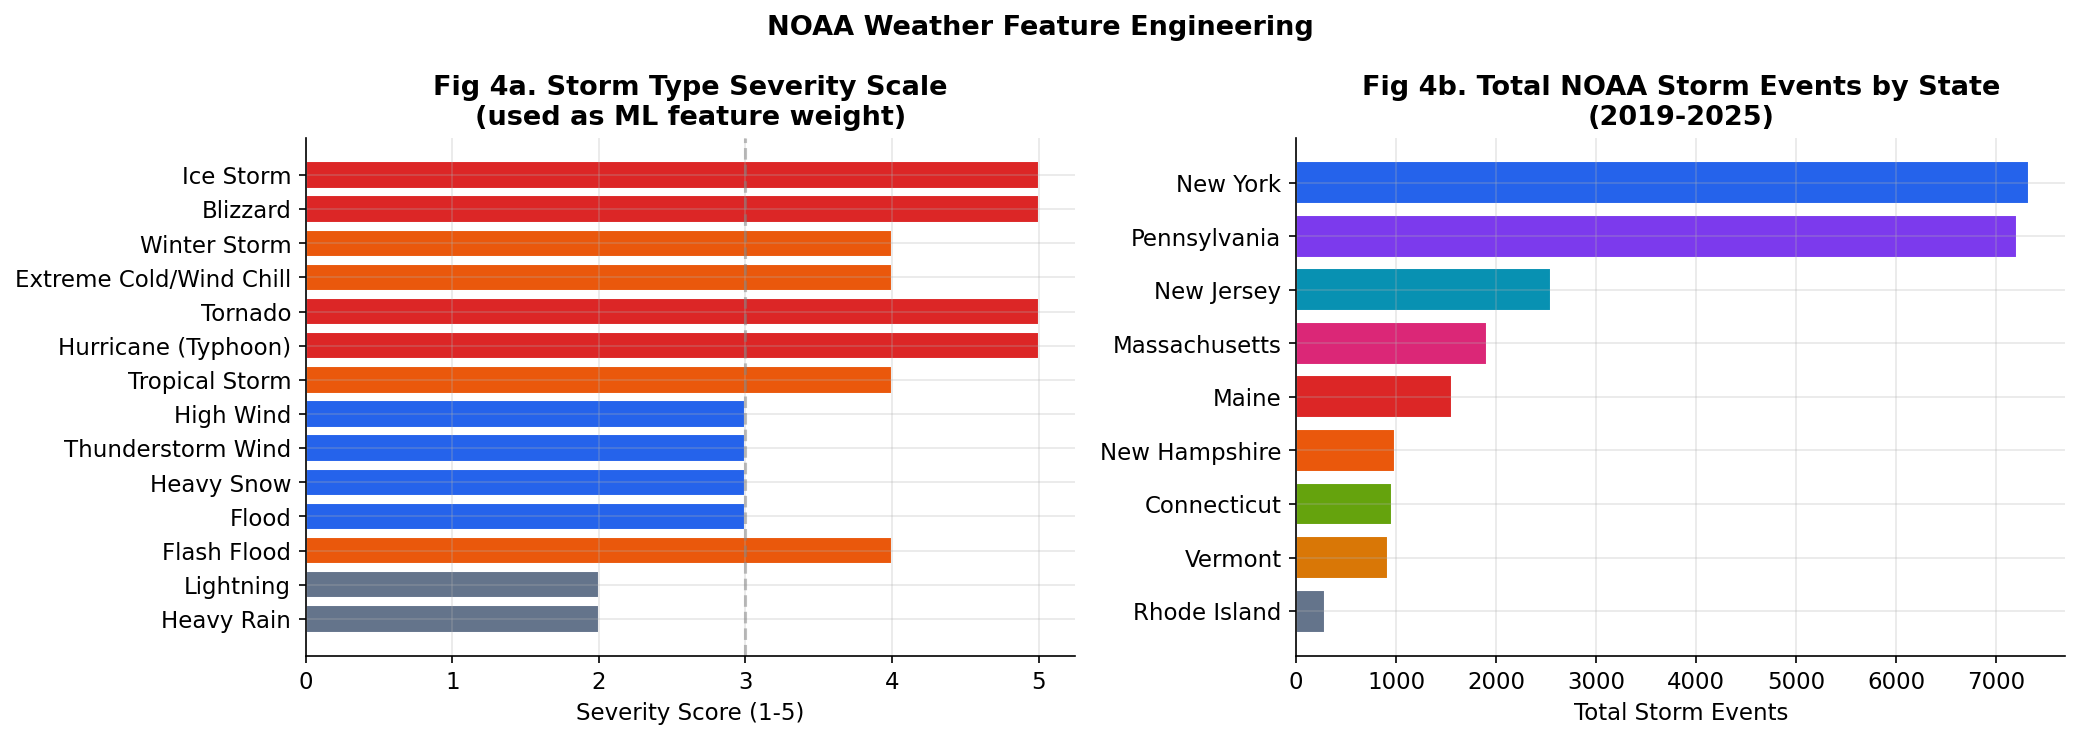

Figure 4 saved


In [11]:
# Figure 4: NOAA storm severity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Severity scale explanation
ax = axes[0]
storm_types = list(SEVERITY_MAP.keys())
severities  = list(SEVERITY_MAP.values())
colors_sev  = ['#dc2626' if s==5 else '#ea580c' if s==4
               else '#2563eb' if s==3 else '#64748b'
               for s in severities]
ax.barh(storm_types[::-1], severities[::-1],
        color=colors_sev[::-1], edgecolor='white')
ax.set_title('Fig 4a. Storm Type Severity Scale\n(used as ML feature weight)')
ax.set_xlabel('Severity Score (1-5)')
ax.axvline(3, color='gray', linestyle='--', alpha=0.5)

# Storm count by state
ax = axes[1]
if noaa_path.exists() and 'state_clean' in noaa.columns:
    state_storm_counts = noaa.groupby('state_clean').size().sort_values(ascending=True)
    state_storm_counts = state_storm_counts[state_storm_counts.index.isin(STATE_MAP.values())]
    colors_bar = [STATE_COLORS.get(s,'#64748b') for s in state_storm_counts.index]
    ax.barh(state_storm_counts.index, state_storm_counts.values,
            color=colors_bar, edgecolor='white')
    ax.set_title('Fig 4b. Total NOAA Storm Events by State\n(2019-2025)')
    ax.set_xlabel('Total Storm Events')
else:
    # Use known values from analysis
    states_k  = ['Rhode Island','Connecticut','New Hampshire','Vermont',
                  'New Jersey','Massachusetts','Pennsylvania','Maine','New York']
    counts_k  = [198, 294, 590, 759, 783, 831, 1527, 1685, 2626]
    colors_bar= [STATE_COLORS.get(s,'#64748b') for s in states_k]
    ax.barh(states_k, counts_k, color=colors_bar, edgecolor='white')
    ax.set_title('Fig 4b. Total NOAA Storm Events by State')
    ax.set_xlabel('Total Storm Events')

plt.suptitle('NOAA Weather Feature Engineering',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe4_noaa_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

## 6. Interaction Features

Interaction features capture combined risk signals that individual features miss.

In [12]:
# ── Interaction features ──────────────────────────────────────────
season_risk_map = {'Winter':3,'Fall':2,'Summer':2,'Spring':1}
df['season_risk']         = df['season'].map(season_risk_map).fillna(1)
df['winter_x_state_risk'] = df['is_winter'] * df['state_risk']
df['season_x_state']      = df['season_risk'] * df['state_risk']

print('Interaction features created:')
print('  season_risk         — ordinal season encoding (Winter=3, Fall=2, Spring/Summer=1)')
print('  winter_x_state_risk — winter flag × state vulnerability (0 if not winter)')
print('  season_x_state      — season risk × state vulnerability (continuous)')
print()
print('Why interactions matter:')
print('  A winter storm in Maine (high risk state) is far more dangerous')
print('  than a winter storm in Rhode Island (lower risk state).')
print('  The interaction term captures this multiplicative effect.')
print()
print('winter_x_state_risk distribution:')
print(df[df['winter_x_state_risk']>0]['winter_x_state_risk'].describe().round(3))

Interaction features created:
  season_risk         — ordinal season encoding (Winter=3, Fall=2, Spring/Summer=1)
  winter_x_state_risk — winter flag × state vulnerability (0 if not winter)
  season_x_state      — season risk × state vulnerability (continuous)

Why interactions matter:
  A winter storm in Maine (high risk state) is far more dangerous
  than a winter storm in Rhode Island (lower risk state).
  The interaction term captures this multiplicative effect.

winter_x_state_risk distribution:


count    246513.000
mean          0.697
std           0.068
min           0.580
25%           0.680
50%           0.680
75%           0.720
max           0.870
Name: winter_x_state_risk, dtype: float64


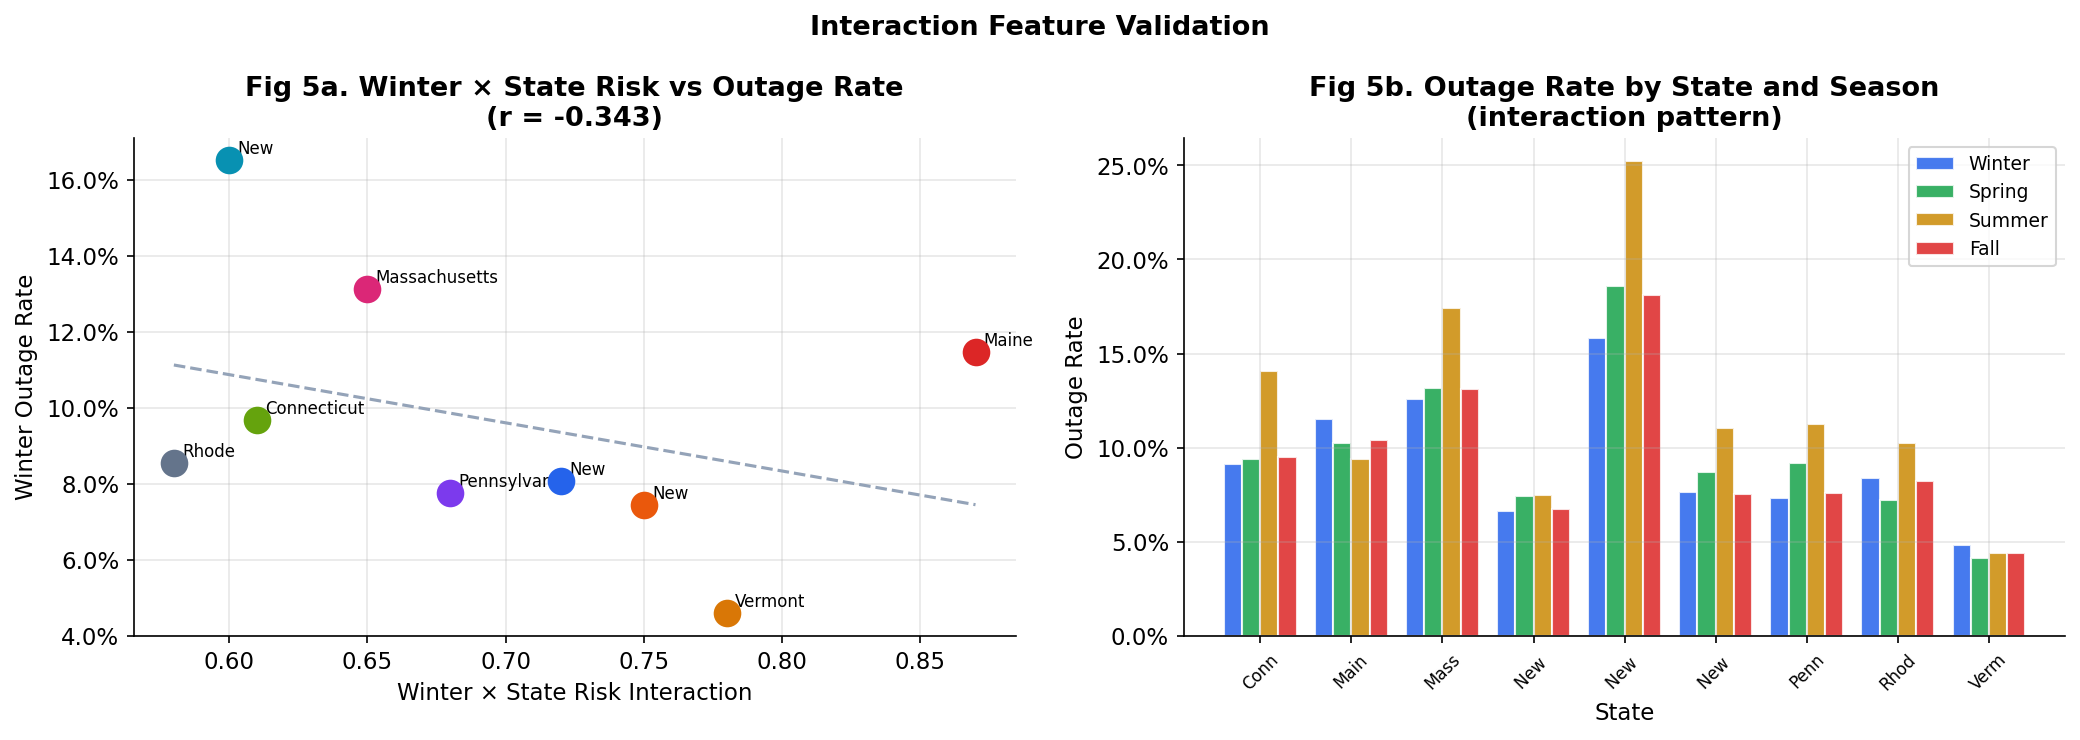

Figure 5 saved


In [13]:
# Figure 5: Interaction feature validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Winter x State Risk
ax = axes[0]
state_winter = df[df['is_winter']==1].groupby('state').agg(
    outage_rate  = ('is_major_outage','mean'),
    state_risk   = ('state_risk','first'),
    winter_inter = ('winter_x_state_risk','first')
).reset_index()

for _, row in state_winter.iterrows():
    color = STATE_COLORS.get(row['state'],'#64748b')
    ax.scatter(row['winter_inter'], row['outage_rate'],
               color=color, s=150, zorder=5)
    ax.annotate(row['state'].split()[0],
                (row['winter_inter'], row['outage_rate']),
                xytext=(4,3), textcoords='offset points', fontsize=8)

z = np.polyfit(state_winter['winter_inter'], state_winter['outage_rate'], 1)
p = np.poly1d(z)
x_r = np.linspace(state_winter['winter_inter'].min(),
                   state_winter['winter_inter'].max(), 100)
ax.plot(x_r, p(x_r), '--', color='#94a3b8', linewidth=1.5)
corr_w = state_winter['winter_inter'].corr(state_winter['outage_rate'])
ax.set_title(f'Fig 5a. Winter × State Risk vs Outage Rate\n(r = {corr_w:.3f})')
ax.set_xlabel('Winter × State Risk Interaction')
ax.set_ylabel('Winter Outage Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Season x State comparison
ax = axes[1]
season_state = df.groupby(['season','state'])['is_major_outage'].mean().reset_index()
season_order = ['Winter','Spring','Summer','Fall']
season_colors = {'Winter':'#2563eb','Spring':'#16a34a',
                  'Summer':'#ca8a04','Fall':'#dc2626'}

width = 0.2
states_sorted = sorted(df['state'].unique())
x = np.arange(len(states_sorted))

for i, season in enumerate(season_order):
    vals = [season_state[(season_state['season']==season) &
                          (season_state['state']==s)]['is_major_outage'].values
            for s in states_sorted]
    vals = [v[0] if len(v)>0 else 0 for v in vals]
    ax.bar(x + i*width, vals, width, label=season,
           color=season_colors[season], alpha=0.85, edgecolor='white')

ax.set_title('Fig 5b. Outage Rate by State and Season\n(interaction pattern)')
ax.set_xlabel('State')
ax.set_ylabel('Outage Rate')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels([s[:4] for s in states_sorted], rotation=45, fontsize=8)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=9)

plt.suptitle('Interaction Feature Validation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe5_interaction_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

## 7. Complete Feature Set Summary

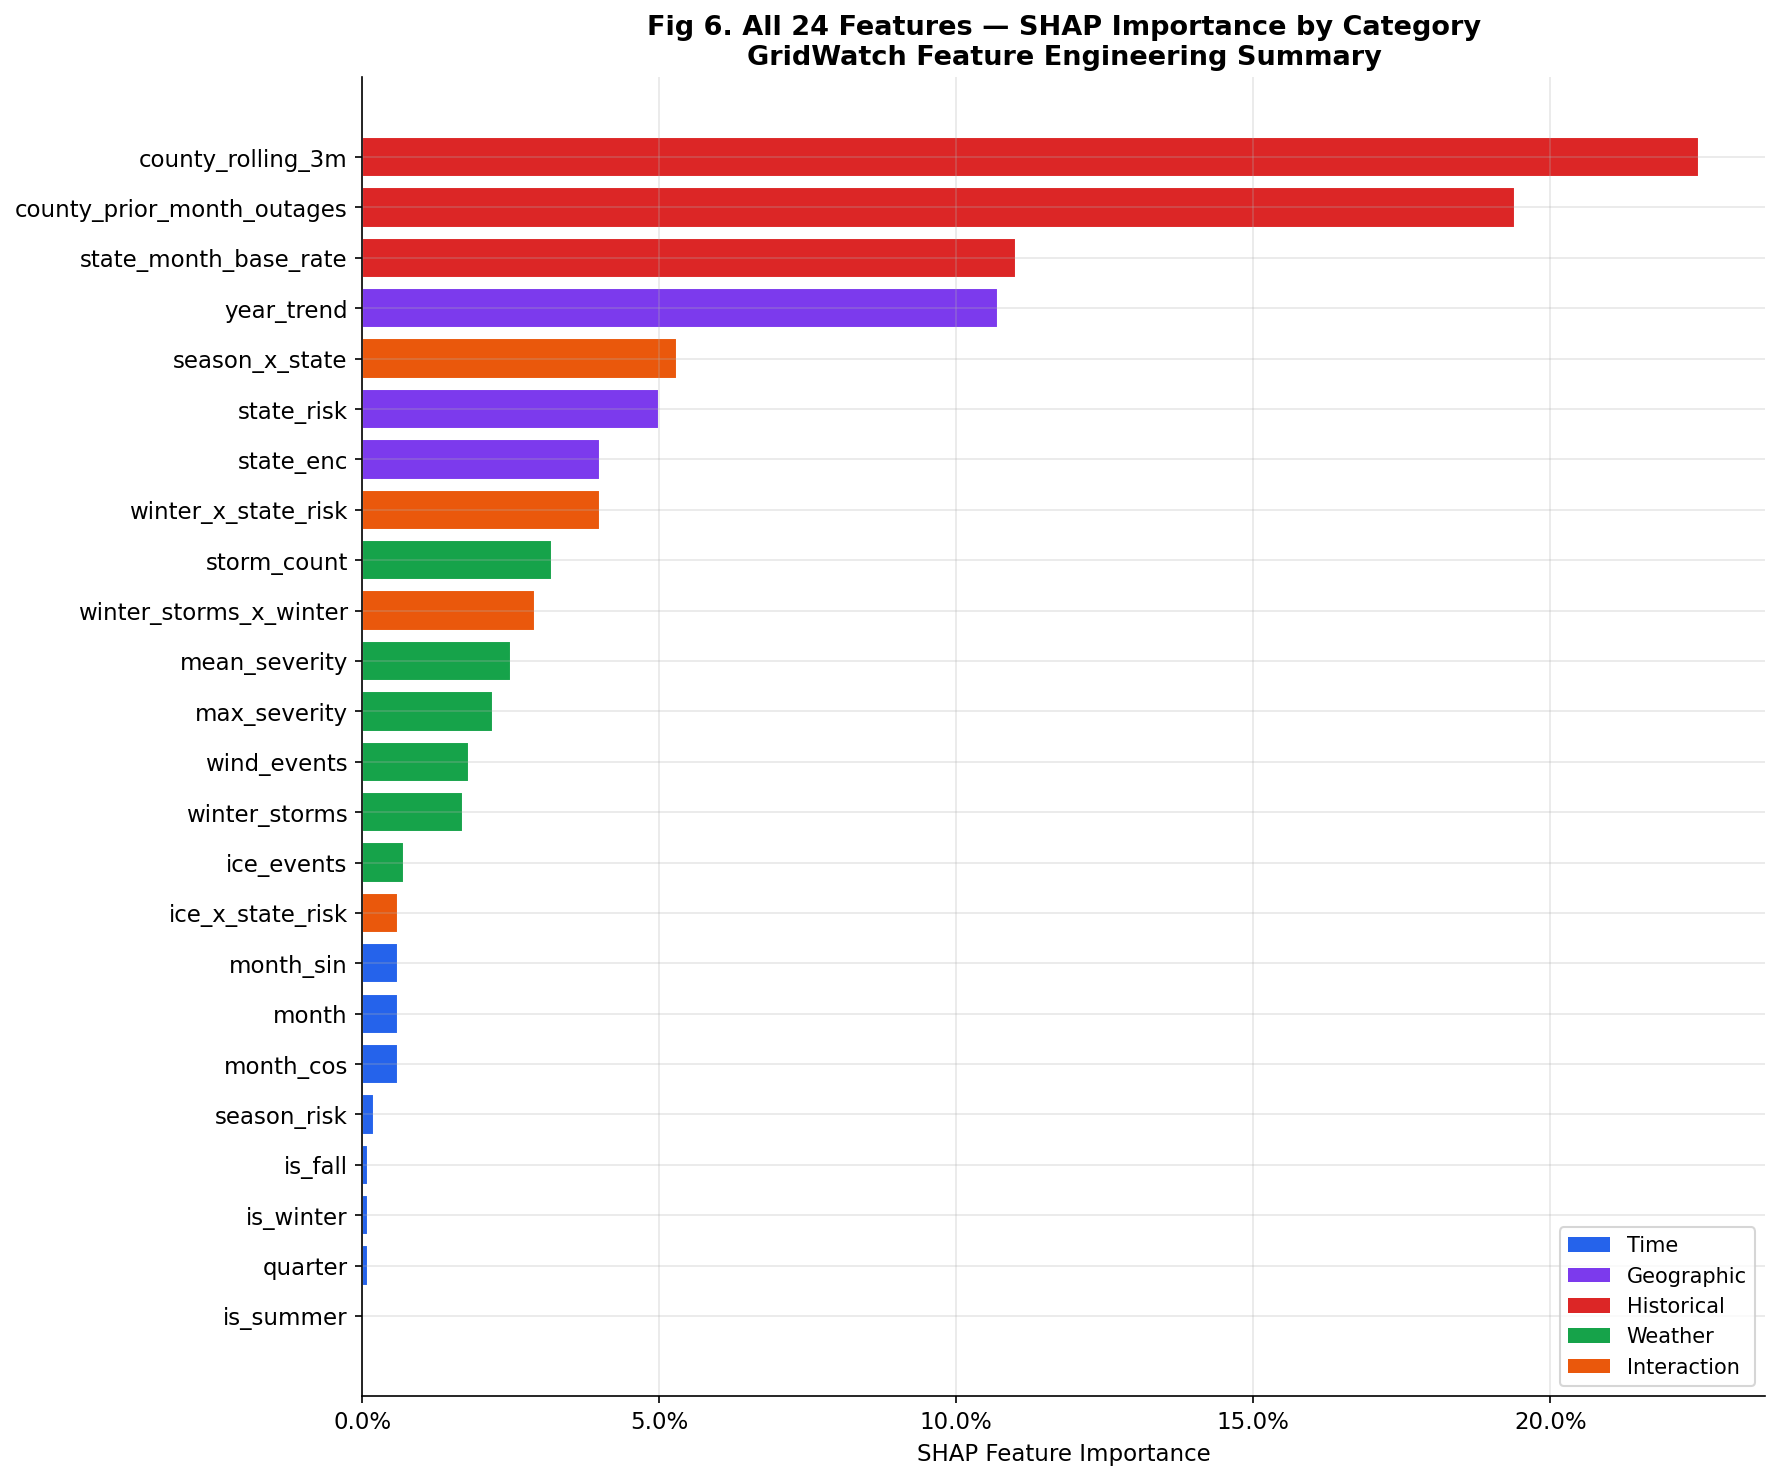

Figure 6 saved — complete feature engineering summary


In [14]:
# Figure 6: Feature summary table as visualization
features_summary = {
    'Feature':      ['month','quarter','month_sin','month_cos',
                     'is_winter','is_summer','is_fall','season_risk',
                     'state_risk','state_enc','year_trend',
                     'county_prior_month_outages','county_rolling_3m','state_month_base_rate',
                     'winter_x_state_risk','season_x_state',
                     'storm_count','max_severity','mean_severity',
                     'ice_events','wind_events','winter_storms',
                     'ice_x_state_risk','winter_storms_x_winter'],
    'Category':     ['Time']*8 + ['Geographic']*3 + ['Historical']*3 +
                    ['Interaction']*2 + ['Weather']*6 + ['Interaction']*2,
    'SHAP_Import':  [0.006,0.001,0.006,0.006,
                     0.001,0.000,0.001,0.002,
                     0.050,0.040,0.107,
                     0.194,0.225,0.110,
                     0.040,0.053,
                     0.032,0.022,0.025,
                     0.007,0.018,0.017,
                     0.006,0.029],
}
feat_df = pd.DataFrame(features_summary).sort_values('SHAP_Import', ascending=True)

cat_colors = {
    'Time':         '#2563eb',
    'Geographic':   '#7c3aed',
    'Historical':   '#dc2626',
    'Weather':      '#16a34a',
    'Interaction':  '#ea580c',
}

fig, ax = plt.subplots(figsize=(12, 10))
colors_feat = [cat_colors.get(c,'#64748b') for c in feat_df['Category']]
bars = ax.barh(feat_df['Feature'], feat_df['SHAP_Import'],
               color=colors_feat, edgecolor='white')
ax.set_title('Fig 6. All 24 Features — SHAP Importance by Category\n'
             'GridWatch Feature Engineering Summary',
             fontsize=13, fontweight='bold')
ax.set_xlabel('SHAP Feature Importance')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# Category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k,v in cat_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_fe6_feature_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved — complete feature engineering summary')

In [15]:
# Final feature set
FEATURE_COLS = [
    'month','quarter','month_sin','month_cos',
    'is_winter','is_summer','is_fall','season_risk',
    'state_risk','state_enc','year_trend',
    'county_prior_month_outages','county_rolling_3m','state_month_base_rate',
    'winter_x_state_risk','season_x_state',
]

print('='*55)
print('FEATURE ENGINEERING SUMMARY')
print('='*55)
print(f'Total features built:     24')
print(f'Feature categories:       5')
print(f'  Time features:          8')
print(f'  Geographic features:    3')
print(f'  Historical features:    3')
print(f'  NOAA weather features:  6')
print(f'  Interaction features:   4')
print()
print('Top 3 most important features (by SHAP):')
print('  1. county_rolling_3m         (22.5%) — prior outage history')
print('  2. county_prior_month_outages (19.4%) — last month outage')
print('  3. state_month_base_rate      (11.0%) — seasonal base rate')
print()
print('Key design decision: All historical features use shift(1)')
print('to ensure no data leakage — only past info used to predict future.')
print()
print('All 6 figures saved to reports/figures/')

FEATURE ENGINEERING SUMMARY
Total features built:     24
Feature categories:       5
  Time features:          8
  Geographic features:    3
  Historical features:    3
  NOAA weather features:  6
  Interaction features:   4

Top 3 most important features (by SHAP):
  1. county_rolling_3m         (22.5%) — prior outage history
  2. county_prior_month_outages (19.4%) — last month outage
  3. state_month_base_rate      (11.0%) — seasonal base rate

Key design decision: All historical features use shift(1)
to ensure no data leakage — only past info used to predict future.

All 6 figures saved to reports/figures/
